In [1]:
import numpy as np
import pandas as pd

In [2]:
df1 = pd.read_csv("/content/acDetails.txt", sep = "\t")
df2 = pd.read_csv("/content/demoDetails.csv", index_col = 0)
df3 = pd.read_csv("/content/serviceDetails.csv", index_col = 0)

## Duplicates were removed from the dataset

In [3]:
df1.columns

Index(['customerID', 'tenure', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='object')

In [4]:
df2.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents'], dtype='object')

In [5]:
df3.columns

Index(['customerID', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Churn'],
      dtype='object')

In [6]:
print(len(df1))
print(len(df2))
print(len(df3))

251
251
251


In [7]:
len(np.unique(df1["customerID"]))

250

In [8]:
len(np.unique(df2["customerID"]))

250

In [9]:
len(np.unique(df3["customerID"]))

250

In [10]:
df1.duplicated(subset = ["customerID"], keep = False)

,0
1,False
2,False
3,False
4,False
5,False
...,...
247,False
248,False
249,False
250,False


In [11]:
df1[df1.duplicated(subset = ["customerID"], keep = False)]

,customerID,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
46,9067-SQTNS,44,One year,No,Bank transfer (automatic),20.6,926.0
251,9067-SQTNS,44,One year,No,Bank transfer (automatic),20.6,926.0


In [12]:
df2.duplicated(subset = ["customerID"], keep = False)

,0
1,False
2,False
3,False
4,False
5,False
...,...
247,False
248,False
249,False
250,False


In [13]:
df2[df2.duplicated(subset = ["customerID"], keep = False)]

,customerID,gender,SeniorCitizen,Partner,Dependents
46,9067-SQTNS,Male,0.0,Yes,Yes
251,9067-SQTNS,Male,0.0,Yes,Yes


In [14]:
df3.duplicated(subset = ["customerID"], keep = False)

,0
1,False
2,False
3,False
4,False
5,False
...,...
247,False
248,False
249,False
250,False


In [15]:
df3[df3.duplicated(subset = ["customerID"], keep = False)]

,customerID,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Churn
46,9067-SQTNS,Yes,No,No,Yes,Yes,No internet service,No internet service,Yes,No internet service,No
251,9067-SQTNS,Yes,No,No,Yes,Yes,No internet service,No internet service,Yes,No internet service,No


In [16]:
df1 = df1.drop_duplicates()
df2 = df2.drop_duplicates()
df3 = df3.drop_duplicates()

## check whether the customer ID is commmon across all the files

In [19]:
df1["customerID"].equals(df2["customerID"]) and df2["customerID"].equals(df3["customerID"])

True

# Merge the files into a single file

In [20]:
churn = pd.merge(df1, df2, on = "customerID")
churn.columns

Index(['customerID', 'tenure', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents'],
      dtype='object')

In [21]:
churn = pd.merge(churn, df3, on = "customerID")
churn.columns

Index(['customerID', 'tenure', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Churn'],
      dtype='object')

In [22]:
df = churn.copy(deep = True)

# Data Exploration

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        250 non-null    object 
 1   tenure            250 non-null    object 
 2   Contract          250 non-null    object 
 3   PaperlessBilling  250 non-null    object 
 4   PaymentMethod     250 non-null    object 
 5   MonthlyCharges    240 non-null    float64
 6   TotalCharges      235 non-null    float64
 7   gender            250 non-null    object 
 8   SeniorCitizen     245 non-null    float64
 9   Partner           250 non-null    object 
 10  Dependents        250 non-null    object 
 11  PhoneService      250 non-null    object 
 12  MultipleLines     250 non-null    object 
 13  InternetService   250 non-null    object 
 14  OnlineSecurity    250 non-null    object 
 15  OnlineBackup      250 non-null    object 
 16  DeviceProtection  250 non-null    object 
 1

In [24]:
df["tenure"].value_counts()

,count
tenure,
One,20
72,15
2,9
Four,9
9,8
...,...
992,1
40,1
969,1


In [25]:
cat_data = df.select_dtypes(include = "object").copy()
cat_data.columns

Index(['customerID', 'tenure', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Churn'],
      dtype='object')

In [26]:
cat_data = cat_data.drop(["customerID", "tenure"], axis = 1)
frequency = cat_data.apply(lambda x: x.value_counts()).T.stack()
frequency

Contract          Month-to-month               133.0
                  One year                      55.0
                  Two year                      62.0
PaperlessBilling  No                            98.0
                  Yes                          152.0
PaymentMethod     Bank transfer (automatic)     58.0
                  Credit card (automatic)       57.0
                  Electronic check              80.0
                  Mailed check                  55.0
gender            Female                       124.0
                  Male                         126.0
Partner           No                           126.0
                  Yes                          124.0
Dependents        1@#                            6.0
                  No                           171.0
                  Yes                           73.0
PhoneService      No                            27.0
                  Yes                          223.0
MultipleLines     No                           113.0
                  No phone service              27.0
                  Yes                          110.0
InternetService   DSL                           86.0
                  Fiber optic                  113.0
                  No                            51.0
OnlineSecurity    No                           132.0
                  No internet service           33.0
                  Yes                           85.0
OnlineBackup      No                           101.0
                  No internet service           33.0
                  Yes                          116.0
DeviceProtection  No                           107.0
                  No internet service           51.0
                  Yes                           92.0
TechSupport       No                           130.0
                  No internet service           51.0
                  Yes                           69.0
StreamingTV       No                           100.0
                  No internet service           43.0
                  Yes                          107.0
StreamingMovies   No                           104.0
                  No internet service           61.0
                  Yes                           85.0
Churn             No                           172.0
                  Yes                           78.0
dtype: float64

In [27]:
df.describe()

,MonthlyCharges,TotalCharges,SeniorCitizen
count,240.000000,235.000000,245.000000
mean,63.694792,2307.926809,0.138776
std,30.730847,2292.524824,0.346420
min,3.500000,18.850000,0.000000
25%,33.937500,447.250000,0.000000
50%,70.925000,1337.500000,0.000000
75%,89.150000,3883.775000,0.000000
max,115.100000,8337.450000,1.000000


In [28]:
df["tenure"] = df["tenure"].replace("One", 1)
df["tenure"] = df["tenure"].replace("Four", 4)
df["tenure"] = df["tenure"].astype(int)
df["tenure"]

,tenure
0,1
1,39
2,2
3,6
4,4
...,...
245,4
246,56
247,1
248,42


In [29]:
pd.crosstab(index = df["Dependents"], columns = "count")

col_0,count
Dependents,
1@#,6
No,171
Yes,73


In [30]:
df["Dependents"] = df["Dependents"].replace("1@#", "No")

In [31]:
pd.crosstab(index = df["Dependents"], columns = "count")

col_0,count
Dependents,
No,177
Yes,73


In [32]:
df["customerID"]

,customerID
0,8260-NGFNY
1,2359-QWQUL
2,6598/RFFVI
3,IXSTS-8780
4,2674/MIAHT
...,...
245,8111-RKSPX
246,6922-NCEDI
247,5192-EBGOV
248,8495-PRWFH


In [33]:
len_ind = [i for i, value in enumerate(df.customerID) if len(value)!=10]
len_ind

[]

In [34]:
import re
pattern = '^[0-9]{4,4}-[A-Z]{5,5}'

p = re.compile(pattern)
type(p)

q = [i for i, value in enumerate(df.customerID) if p.match(str(value)) == None]
print(q)

[2, 3, 4, 6]


In [35]:
fp1 = re.compile('^[A-Z]{5,5}-[0-9]{4,4}')
fp2 = re.compile('^[0-9]{4,4}/[A-Z]{5,5}')

In [36]:
for i in q:
  false_str = str(df.customerID[i])
  if (fp1.match(false_str)):
    str_split = false_str.split("-")
    df.customerID[i] = str_split[1] + "-" + str_split[0]
  elif(fp2.match(false_str)):
    df.customerID[i] = false_str.replace("/", "-")

/tmp/ipykernel_42367/323286964.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.customerID[i] = false_str.replace("/", "-")
/tmp/ipykernel_42367/323286964.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.customerID[i] = str_split[1] + "-" + str_split[0]
/tmp/ipykernel_42367/323286964.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.customerID[i] = false_str.replace("/", "-")
/tmp/ipykernel_42367/323286964.py:7: Settin

In [38]:
y = df[(df.InternetService == "No")]
z = y.iloc[:,13:20]
z

,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
2,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service
8,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service
13,No,Yes,Yes,No internet service,No internet service,Yes,No internet service
14,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service
15,No,Yes,Yes,No internet service,No internet service,Yes,No internet service
18,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service
20,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service
23,No,Yes,Yes,No internet service,No internet service,Yes,No internet service
24,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service
31,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service


In [39]:
for i, row in z.iterrows():
  yes_cnt = row.str.count('Yes').sum()
  if (yes_cnt >= 2):
    z.loc[i].InternetService = 'Yes'
  else:
    z.loc[i,:] = 'No internet service'
z

,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
2,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service
8,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service
13,Yes,Yes,Yes,No internet service,No internet service,Yes,No internet service
14,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service
15,Yes,Yes,Yes,No internet service,No internet service,Yes,No internet service
18,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service
20,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service
23,Yes,Yes,Yes,No internet service,No internet service,Yes,No internet service
24,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service
31,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service


In [40]:
df.tenure.describe()

,tenure
count,250.000000
mean,55.944000
std,147.819781
min,1.000000
25%,8.250000
50%,30.500000
75%,60.500000
max,1008.000000


<Axes: ylabel='tenure'>

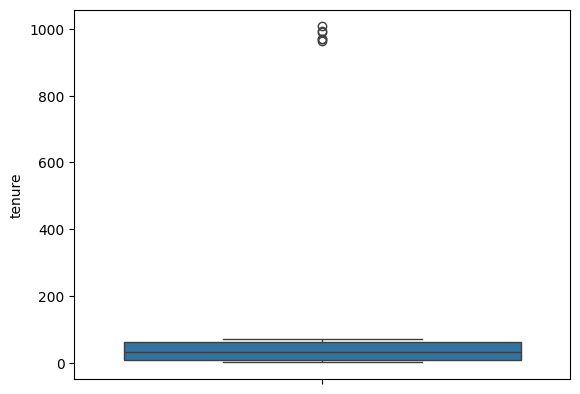

In [41]:
import seaborn as sns
sns.boxplot(y = df["tenure"])

In [42]:
df["tenure"] = np.where(df["tenure"] >= 500,
                        df["tenure"].median(), df["tenure"])

In [43]:
df["tenure"].describe(include = "all")

,tenure
count,250.000000
mean,33.084000
std,25.024946
min,1.000000
25%,8.250000
50%,30.250000
75%,57.750000
max,72.000000


<Axes: ylabel='tenure'>

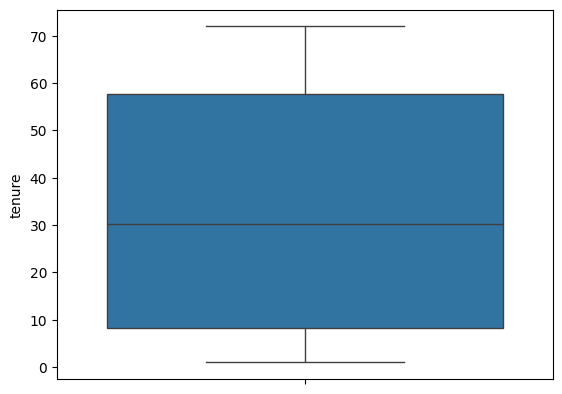

In [44]:
sns.boxplot(y = df["tenure"])

In [45]:
df.isnull().sum()

,0
customerID,0
tenure,0
Contract,0
PaperlessBilling,0
PaymentMethod,0
MonthlyCharges,10
TotalCharges,15
gender,0
SeniorCitizen,5
Partner,0


In [52]:
df.describe()

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen
count,250.000000,240.000000,235.000000,250.000000
mean,33.084000,63.694792,2307.926809,0.136000
std,25.024946,30.730847,2292.524824,0.343476
min,1.000000,3.500000,18.850000,0.000000
25%,8.250000,33.937500,447.250000,0.000000
50%,30.250000,70.925000,1337.500000,0.000000
75%,57.750000,89.150000,3883.775000,0.000000
max,72.000000,115.100000,8337.450000,1.000000


In [49]:
df['SeniorCitizen'].fillna(df['SeniorCitizen'].mode()[0], inplace = True)
df['SeniorCitizen'].isnull().sum()

/tmp/ipykernel_42367/292224993.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['SeniorCitizen'].fillna(df['SeniorCitizen'].mode()[0], inplace = True)


np.int64(0)

<Axes: xlabel='TotalCharges', ylabel='Churn'>

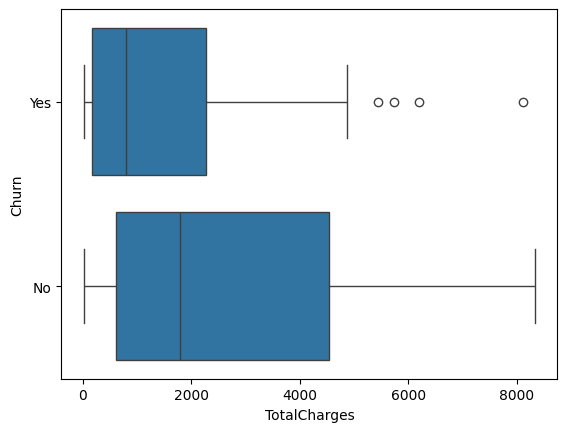

In [54]:
sns.boxplot(x = df["TotalCharges"], y = df['Churn'])

In [56]:
df['TotalCharges'] = df.groupby('Churn')['TotalCharges']\
.transform(lambda x: x.fillna(x.mean()))
df.TotalCharges.isnull().sum()

np.int64(0)

In [57]:
df['MonthlyCharges'].mean()

np.float64(63.69479166666667)

<Axes: xlabel='MonthlyCharges', ylabel='Churn'>

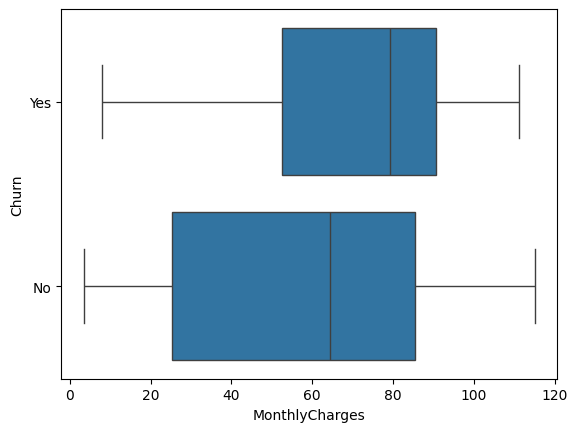

In [58]:
sns.boxplot(x = df['MonthlyCharges'], y = df['Churn'])

In [59]:
df['MonthlyCharges'] = df.groupby('Churn')['MonthlyCharges']\
.transform(lambda x: x.fillna(x.mean()))
df.TotalCharges.isnull().sum()

np.int64(0)

In [60]:
import random
p1 = list(range(1, 20))
print(p1)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


In [61]:
SRSWOR = random.sample(population = p1, k = 10)
SRSWOR

[3, 18, 12, 4, 10, 9, 16, 14, 7, 2]

In [62]:
p2 = list(range(1, 25))
print(p2)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]


In [65]:
SRSWR = random.choices(population = p2, k = 10)
SRSWR

[15, 11, 3, 11, 6, 22, 22, 9, 24, 5]

In [66]:
num_col = df.select_dtypes(exclude=[object])
num_col.corr()

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen
tenure,1.000000,0.154096,0.788598,-0.009745
MonthlyCharges,0.154096,1.000000,0.535941,0.180592
TotalCharges,0.788598,0.535941,1.000000,0.053669
SeniorCitizen,-0.009745,0.180592,0.053669,1.000000


In [67]:
desc = df.describe(include="number").T
skew = df.select_dtypes(include=["int64", "float64"]).skew(numeric_only = True).to_frame("skew")
desc.join(skew, how="left")

,count,mean,std,min,25%,50%,75%,max,skew
tenure,250.0,33.084000,25.024946,1.00,8.2500,30.250,57.7500,72.00,0.177412
MonthlyCharges,250.0,63.689162,30.125203,3.50,35.6125,70.475,87.5500,115.10,-0.275577
TotalCharges,250.0,2316.801732,2226.018166,18.85,481.5750,1462.696,3504.3125,8337.45,0.993832
SeniorCitizen,250.0,0.136000,0.343476,0.00,0.0000,0.000,0.0000,1.00,2.136599
